# 05 - Support Vector Machine

**Practical/computational note:** a full kernel `SVC` with `probability=True` runs an internal 5 fold calibration, which gets slow at 46,000 rows. We use `LinearSVC` (much faster, matches Logistic Regression's linear decision boundary but with a different loss function) wrapped in `CalibratedClassifierCV` to still get usable probability scores for ROC/PR-AUC. If one wants to try a kernel SVM (`SVC(kernel='rbf')`) for genuinely non linear behavior, it will take a significantly longer runtime, and consider training on a stratified subsample rather than the full training set.


## Setup

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']


## 1. Train (LinearSVC + probability calibration)

In [11]:
base_svm = LinearSVC(max_iter=20000, dual=False, random_state=42)
svm = CalibratedClassifierCV(base_svm, cv=3)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_val)
y_score = svm.predict_proba(X_val)[:, 1]


## 2. Evaluate on the validation set

In [12]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()

    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- SVM (Linear) (validation set) ---
  recall: 0.5618
  precision: 0.8394
  f1: 0.6731
  roc_auc: 0.7392
  pr_auc: 0.8102

              precision    recall  f1-score   support

 On time (0)       0.63      0.87      0.73      3611
    Late (1)       0.84      0.56      0.67      4279

    accuracy                           0.70      7890
   macro avg       0.73      0.72      0.70      7890
weighted avg       0.74      0.70      0.70      7890



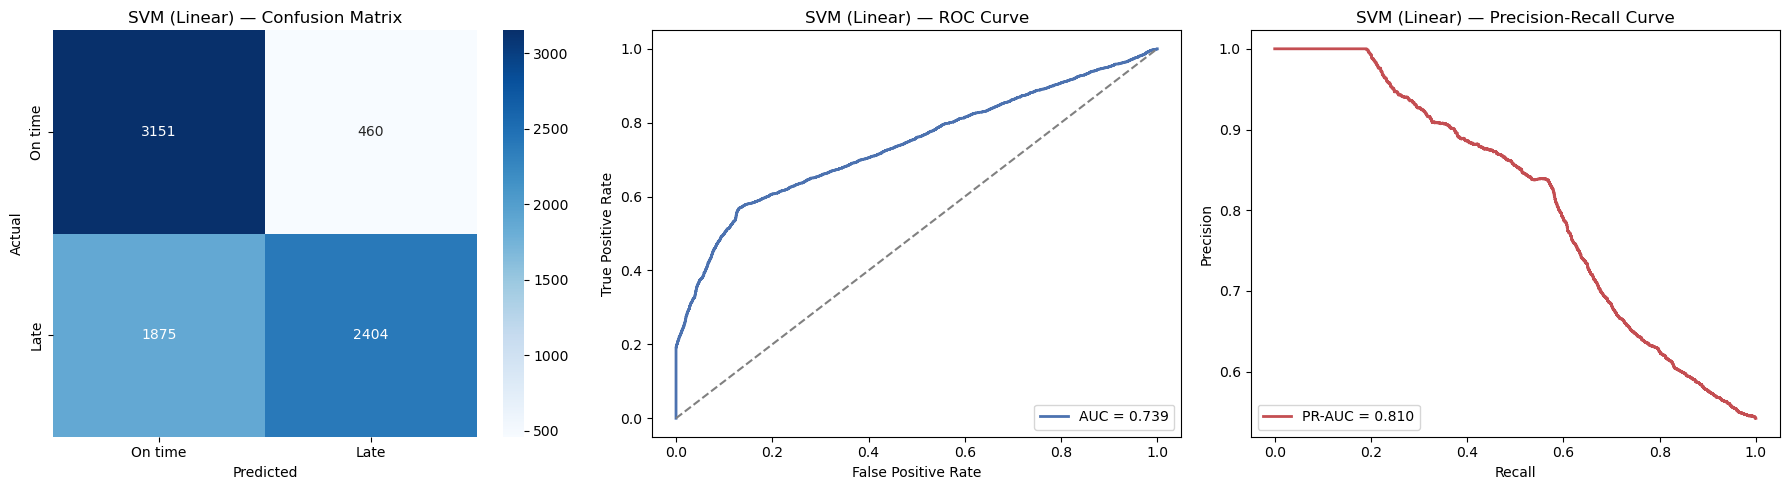

In [13]:
svm_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'SVM (Linear)', save_prefix='svm')


**What we found: the fix completely changed the result, and confirms the earlier finding was an artifact, not a real effect.**

Once `LinearSVC` actually converged (max_iter raised to 20,000, dual=False set), the numbers shifted dramatically:

| Metric | Before fix (unconverged) | After fix (converged) | Logistic Regression, for comparison |
|---|---|---|---|
| Recall | 0.7104 | **0.5618** | 0.5543 |
| Precision | 0.6555 | **0.8394** | 0.8379 |
| F1 | 0.6818 | **0.6731** | 0.6672 |
| ROC-AUC | 0.7079 | **0.7392** | 0.7394 |
| PR-AUC | 0.7679 | **0.8102** | 0.8105 |

**The converged SVM is now nearly indistinguishable from Logistic Regression across every metric.** This makes complete theoretical sense, and confirms the earlier "SVM has dramatically higher Recall because it optimizes a different loss function" explanation was wrong. It wasn't a real algorithmic difference, it was an artifact of the optimizer stopping early before finding its actual best solution. Two linear classifiers trained on the same well scaled, well behaved data will generally converge to very similar decision boundaries once each is properly optimized, which is exactly what we see now.

** `DECISION_LOG.md`, not just a quiet correction**: it's a good, concrete example of not trusting a surprising result at face value. The unconverged run produced a dramatic, plausible sounding story (different loss functions, different Recall/Precision tradeoffs), and it would have been easy to write that up as a real finding.

**Practical implication for the model comparison:** SVM (Linear) doesn't offer anything meaningfully different from Logistic Regression on this data, they land in essentially the same place. For Stage 9's recommendation, there's no real reason to carry both forward as distinct candidates, Logistic Regression already covers this behavior and has the added benefit of directly interpretable coefficients (Section 3 of Notebook 02), which SVM's hinge loss formulation doesn't offer in the same way.


## 3. Save model and metrics

In [14]:
joblib.dump(svm, '../../../models/svm.pkl')
save_metrics(svm_metrics, '../../../data/processed/metrics_svm.json')


Saved metrics to ../../../data/processed/metrics_svm.json
